# DISCOtoolkit quickstart (DISCO v1)

Find samples in the [DISCO](https://disco.bii.a-star.edu.sg/) database by metadata and cell type, download them, and search a gene's expression.
This notebook runs in Google Colab or any Python >= 3.9. It takes a few minutes the first time (the install pulls in scanpy).

## 1. Install

In [ ]:
!pip install -q -U discotoolkit

# or the latest development version from GitHub:
# !pip install -q "git+https://github.com/JinmiaoChenLab/DISCOtoolkit_py.git"

## 2. Check the install and the server

The toolkit is built for DISCO v1 and uses it by default.

In [1]:
import discotoolkit as dt

print("discotoolkit", dt.__version__)
print("server:", dt.get_server())

discotoolkit 1.3.0
server: https://disco.bii.a-star.edu.sg/disco_v3_api/


## 3. (Optional) Check that the server answers everything the toolkit needs

This is the same check the maintainers run. Every line should say PASS.

In [ ]:
!git clone -q --depth 1 https://github.com/JinmiaoChenLab/DISCOtoolkit_py.git DISCOtoolkit_py_src
!python DISCOtoolkit_py_src/tests/test_server_contract.py

## 4. Explore what is in DISCO

In [2]:
print(sorted(map(str, dt.list_metadata_item("tissue")))[:15])      # tissues
print(dt.find_celltype("myoid"))                                    # search the cell ontology

INFO:root:Retrieving ontology from DISCO database


['abdominal wall', 'adipose', 'adrenal gland', 'airway', 'annulus fibrosus', 'aorto-gonad-mesonephros', 'arm', 'artery plaque', 'ascite', 'ascites', 'bile duct', 'bladder', 'blood', 'blood vessel', 'blood, synovium']


['Peritubular myoid cell', 'Peritubular myoid cell progenitor', 'Thymic myoid cell']


## 5. Filter samples

Filter by tissue, disease, platform, project, sample type or cell type. A cell type filter returns the samples that *contain* that cell type, and the download keeps only those cells -- handy for rare ones, such as **thymic myoid cells**.

In [3]:
flt = dt.Filter(
    tissue="thymus",
    platform=["10x3'"],
    sample_type=["control"],
    cell_type="Thymic myoid cell",
    cell_type_confidence="medium",     # "high", "medium" or "all"
    min_cell_per_sample=100,
)
metadata = dt.filter_disco_metadata(flt)
print(metadata.sample_count, "samples,", metadata.cell_count, "cells")
metadata.sample_metadata.head()

INFO:root:Filtering sample


INFO:root:Retrieving ontology from DISCO database


INFO:root:3 samples and 1367 cells were found


3 samples, 1367 cells


,sample_id,project_id,sample_type,tissue,anatomical_site,disease,platform,age_group,cell_sorting,disease_subtype,...,cell_number,median_umi,rds_md5,rds_size,source_cell_line,source_tissue,source_disease,source_cell_type,induced_cell_tissue,collect_time
3553,GSM4466781,GSE147520,control,thymus,NaN,control,10x3',fetal 23 weeks,NaN,NaN,...,535,2265,55054573fd811e49896bf1285416e8e6,55260034,NaN,NaN,NaN,NaN,NaN,NaN
3554,GSM4466782,GSE147520,control,thymus,NaN,control,10x3',fetal 23 weeks,NaN,NaN,...,522,2250,a53069bfae2edeb27a03e2e628ce55ac,57023363,NaN,NaN,NaN,NaN,NaN,NaN
11234,GSM6820845,GSE220830,control,thymus,Medullary,control,10x3',child,CD49f+,NaN,...,310,10427,1ade0ecb63bf6b7c66b388df883291c7,18983894,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Download

Each sample is a 10x `.h5` converted to an AnnData `.h5ad`, with DISCO's cell type annotation in `obs["cell_type"]`. To have something to look at, take three small control-thymus samples from one study (all their cells, about 8,000).

In [4]:
flt = dt.Filter(sample_id=["ERX3806129", "ERX3806130", "ERX3806131"])
metadata = dt.filter_disco_metadata(flt)
print(metadata.sample_count, "samples,", metadata.cell_count, "cells")

dt.download_disco_data(metadata, output_dir="disco_data")   # one .h5ad per sample
!ls -lh disco_data

INFO:root:Filtering sample


INFO:root:3 samples and 8201 cells were found


3 samples, 8201 cells


total 106M
-rw------- 1 runner runner 36M Oct  8 08:49 ERX3806129.h5ad
-rw------- 1 runner runner 36M Oct  8 08:49 ERX3806130.h5ad
-rw------- 1 runner runner 35M Oct  8 08:49 ERX3806131.h5ad


## 7. A UMAP of the downloaded cells

The files are standard AnnData, so scanpy works directly. Coloured by DISCO's labels the UMAP shows the cell types; coloured by sample it shows that the three samples mix.

cell_type
Double positive T cell    4839
Cycling DN/DP T cell       883
Naive CD4 T cell           636
Naive CD8 T cell           550
abT (entry) cell           284
Name: count, dtype: int64


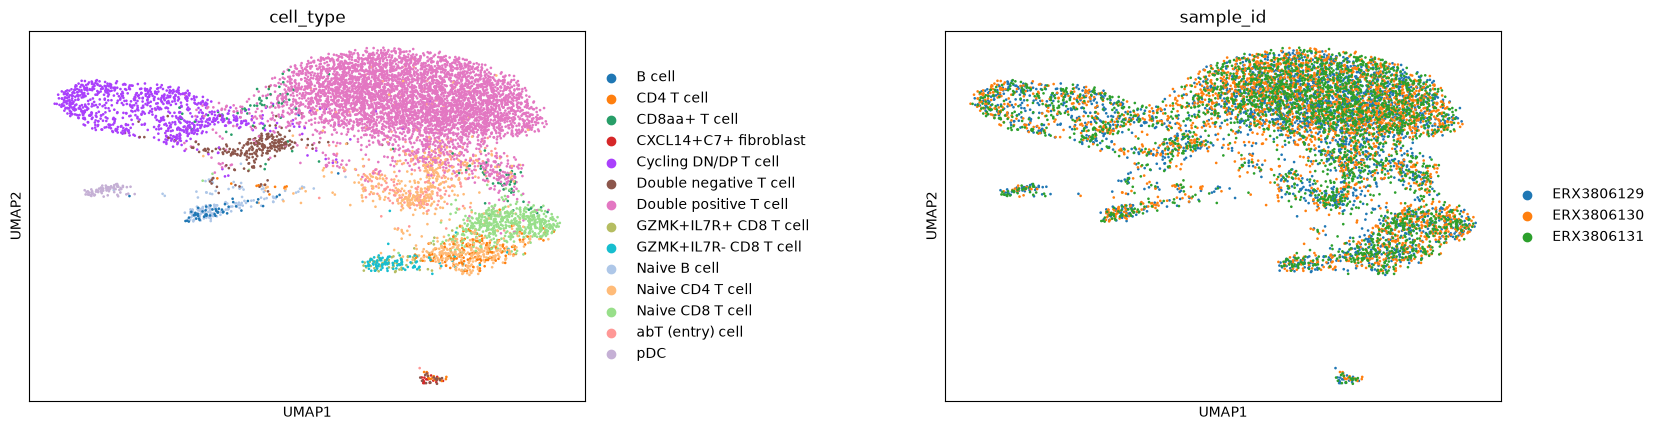

In [5]:
import anndata as ad
import scanpy as sc

ids = list(metadata.sample_metadata["sample_id"])
adata = ad.concat(
    [sc.read_h5ad(f"disco_data/{s}.h5ad") for s in ids],
    keys=ids, index_unique="_",          # barcodes repeat between samples
)
print(adata.obs["cell_type"].value_counts().head(5))

# the standard scanpy workflow: normalise, pick variable genes, embed
sc.pp.filter_genes(adata, min_cells=10)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.pp.pca(adata, mask_var="highly_variable")
sc.pp.neighbors(adata)
sc.tl.umap(adata)

sc.pl.umap(adata, color=["cell_type", "sample_id"], wspace=0.5)

## 8. Marker genes

Expression should agree with the labels: `MKI67` marks the cycling thymocytes and `PTCRA` the double-positive stage.

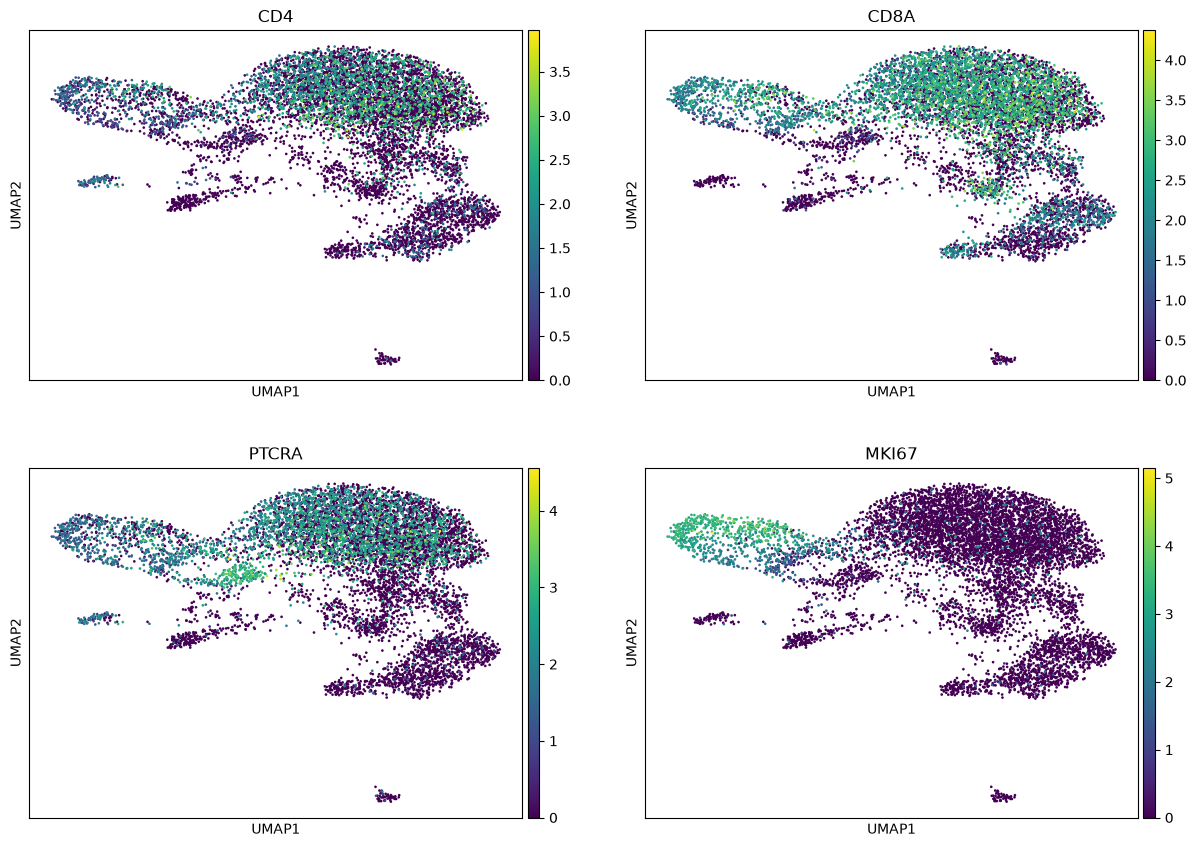

In [6]:
sc.pl.umap(adata, color=["CD4", "CD8A", "PTCRA", "MKI67"], ncols=2, cmap="viridis")

## 9. Cells per type

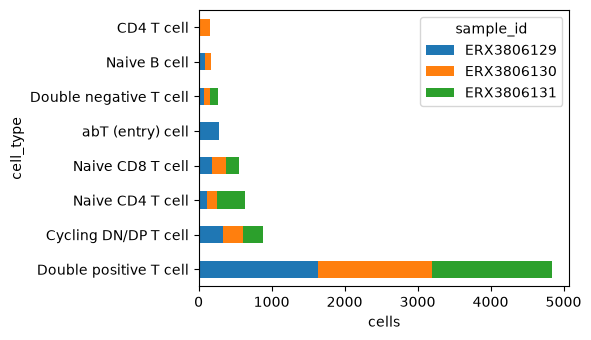

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

counts = pd.crosstab(adata.obs["cell_type"], adata.obs["sample_id"])
top = counts.loc[counts.sum(axis=1).nlargest(8).index]
top.plot.barh(stacked=True, figsize=(6, 3.5))
plt.xlabel("cells"); plt.tight_layout(); plt.show()

## 10. Search a gene across DISCO

Without downloading anything: a gene's expression across all annotated cell types, as on the DISCO website. ACTA1 is highest in skeletal muscle, and also in thymic myoid cells.

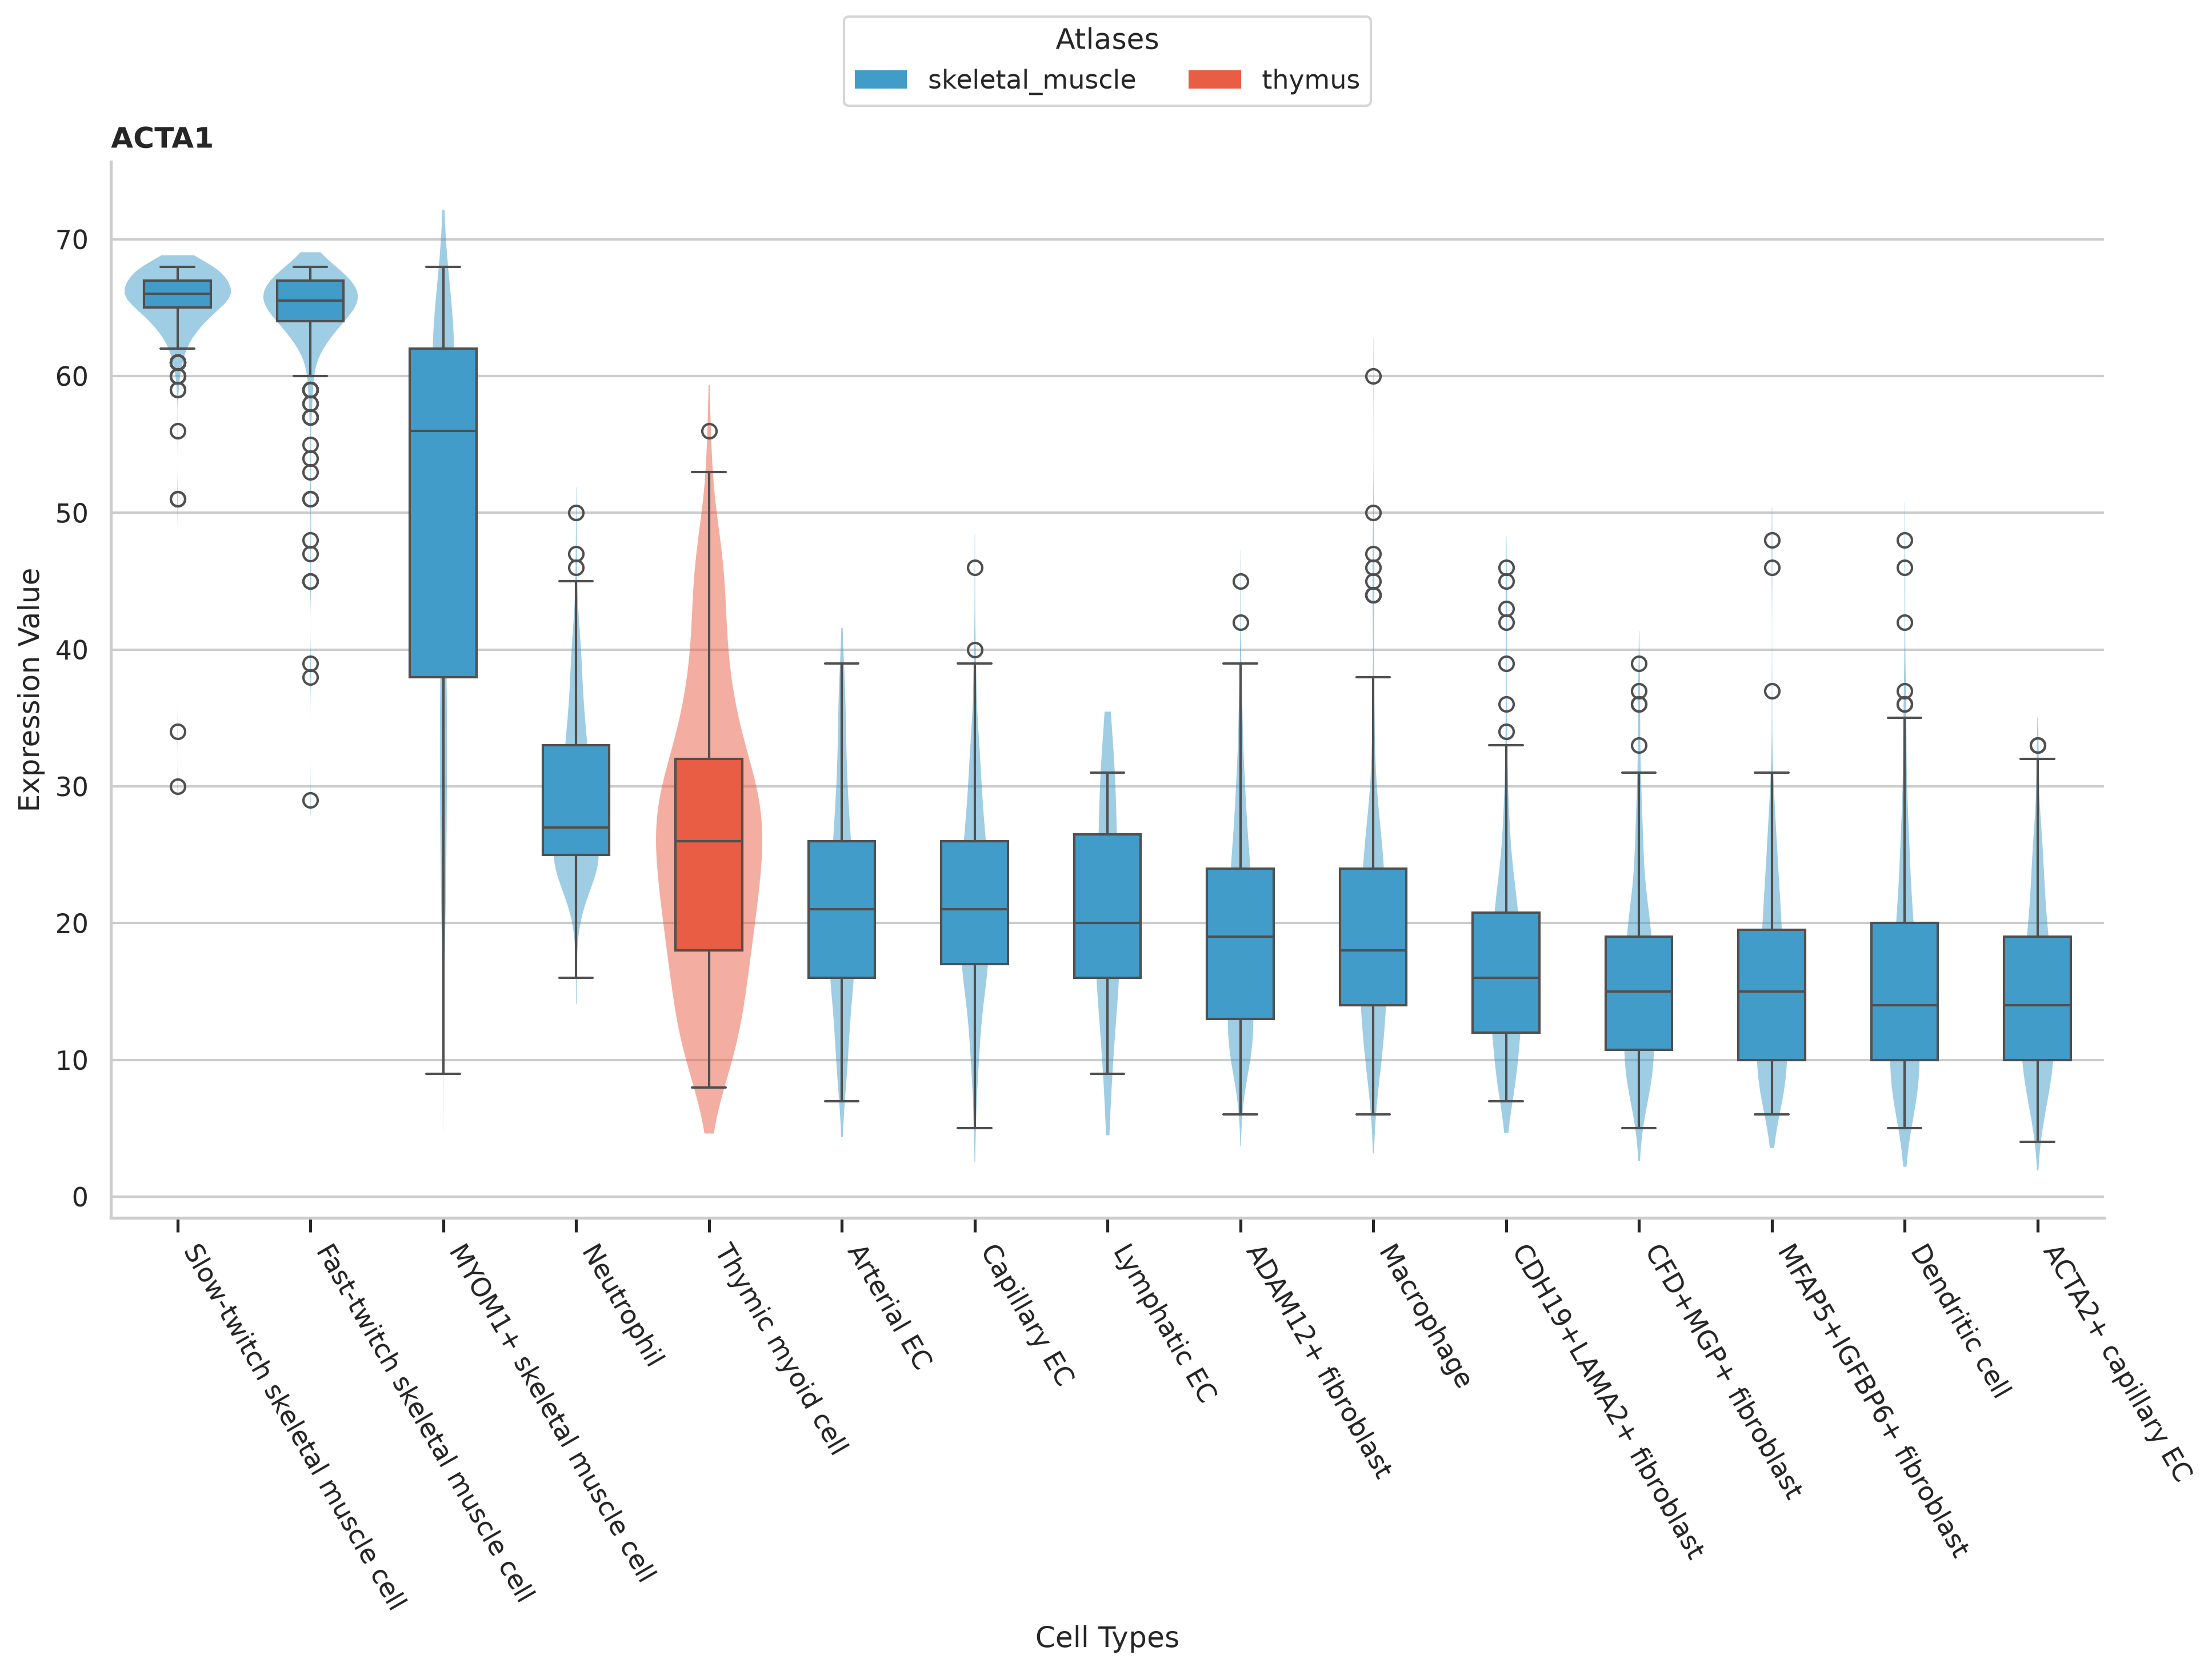

In [8]:
dt.gene_search("ACTA1", atlas=["skeletal_muscle", "thymus"])

## More

- Cell type annotation with CELLiD: [Cell type annotation tutorial](https://disco.bii.a-star.edu.sg/v1/docs/toolkit/guide/stable/CELLiD_celltype_annotation/)
- Gene set enrichment: [Enrichment tutorial](https://disco.bii.a-star.edu.sg/v1/docs/toolkit/guide/stable/scEnrichment/)
- Filtering and downloading in depth: [Download data tutorial](https://disco.bii.a-star.edu.sg/v1/docs/toolkit/guide/stable/download_data/)